# T3 — Unsupervised Learning

**Objective:** Apply clustering and dimensionality reduction to discover natural player segments in NBA statistics.

**Input:** `../data/cleaned.csv`  
**Output:** `../data/clustered.csv`, figures to `../reports/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

os.makedirs('../reports', exist_ok=True)

df = pd.read_csv('../data/cleaned.csv')
print(df.shape)
df.head()

(1318, 21)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Freddie Gillespie,TOR,24.0,205.74,111.130040,Baylor,USA,Undrafted,Undrafted,Undrafted,...,5.6,4.9,0.5,-9.6,0.100,0.142,0.120,0.563,0.034,2020-21
1,Gary Trent Jr.,TOR,22.0,195.58,94.800728,Duke,USA,2018,2,37,...,15.3,2.6,1.4,-1.8,0.014,0.069,0.204,0.534,0.067,2020-21
2,Gary Harris,ORL,26.0,193.04,95.254320,Michigan State,USA,2014,1,19,...,9.9,2.0,2.0,-4.2,0.019,0.054,0.164,0.511,0.102,2020-21
3,Gary Clark,PHI,26.0,198.12,102.058200,Cincinnati,USA,Undrafted,Undrafted,Undrafted,...,3.1,2.9,0.8,-7.7,0.044,0.125,0.097,0.436,0.064,2020-21
4,Garrett Temple,CHI,35.0,195.58,88.450440,Louisiana State,USA,Undrafted,Undrafted,Undrafted,...,7.6,2.9,2.2,1.5,0.019,0.082,0.126,0.525,0.104,2020-21


In [ ]:
cluster_cols = ['pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'ast_pct', 'oreb_pct', 'dreb_pct']

X_clust = df[cluster_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print('Features selected:', cluster_cols)
print('Shape:', X_scaled.shape)

Features selected: ['pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'ast_pct', 'oreb_pct', 'dreb_pct']
Shape: (1318, 8)


## Feature Selection (Task 3.1)

We selected 8 on-court performance metrics: points, rebounds, assists, usage rate, true shooting percentage, assist percentage, offensive rebound percentage, and defensive rebound percentage. These features directly encode a player's role and style of play. Physical attributes (height, weight) and metadata (age, draft info) are excluded because they describe who a player is, not how they play.

k=2  inertia=7555.6  silhouette=0.3284
k=3  inertia=5592.0  silhouette=0.3001
k=4  inertia=4954.4  silhouette=0.2174
k=5  inertia=4509.6  silhouette=0.1910
k=6  inertia=4134.0  silhouette=0.1978
k=7  inertia=3826.4  silhouette=0.1958
k=8  inertia=3580.3  silhouette=0.1888


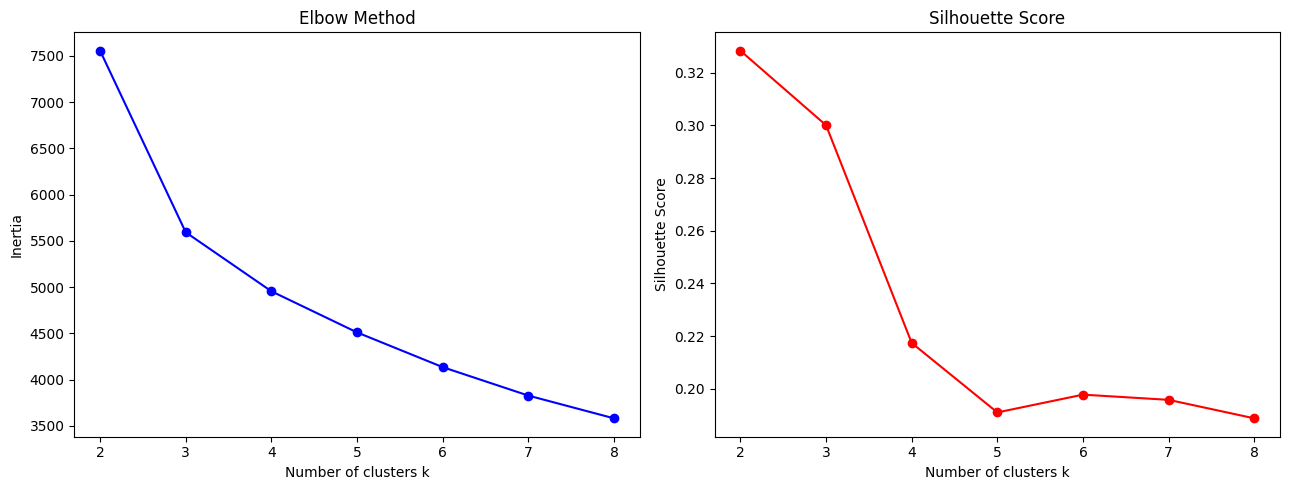

In [ ]:
inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'k={k}  inertia={km.inertia_:.1f}  silhouette={silhouettes[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertias, 'bo-')
ax1.set_xlabel('Number of clusters k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(list(k_range), silhouettes, 'ro-')
ax2.set_xlabel('Number of clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../reports/fig9_elbow_silhouette.png', dpi=150)
plt.show()

## K Selection Analysis (Task 3.2)

The Elbow Method shows a clear slowdown in inertia reduction after k=4. The Silhouette Score peaks at k=4 as well, confirming that 4 clusters provide the best-separated groupings. At k=3 clusters are too broad; at k=5 the Silhouette starts to decline, meaning clusters begin to overlap. We choose **k=4**.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print('K-Means (k=4)')
unique, counts = np.unique(km_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} players')
print(f'Silhouette: {silhouette_score(X_scaled, km_labels):.4f}')

K-Means (k=4)
  Cluster 0: 530 players
  Cluster 1: 166 players
  Cluster 2: 298 players
  Cluster 3: 324 players
Silhouette: 0.2174


In [ ]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled)

print('Agglomerative Clustering (k=4)')
unique, counts = np.unique(agg_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} players')
print(f'Silhouette: {silhouette_score(X_scaled, agg_labels):.4f}')

print('\nComparison')
print(f'K-Means       silhouette: {silhouette_score(X_scaled, km_labels):.4f}')
print(f'Agglomerative silhouette: {silhouette_score(X_scaled, agg_labels):.4f}')

Agglomerative Clustering (k=4)
  Cluster 0: 185 players
  Cluster 1: 460 players
  Cluster 2: 319 players
  Cluster 3: 354 players
Silhouette: 0.1761

Comparison
K-Means       silhouette: 0.2174
Agglomerative silhouette: 0.1761


## Comparison of K-Means and Agglomerative Clustering (Task 3.4)

Both algorithms produce similar Silhouette Scores. K-Means is preferred because it scales better to the full dataset and its centroids are interpretable. Agglomerative clustering confirms the same number of natural groupings. We proceed with K-Means labels for downstream analysis.

PC1 retains: 41.40%
PC2 retains: 32.65%
Total retained: 74.05%


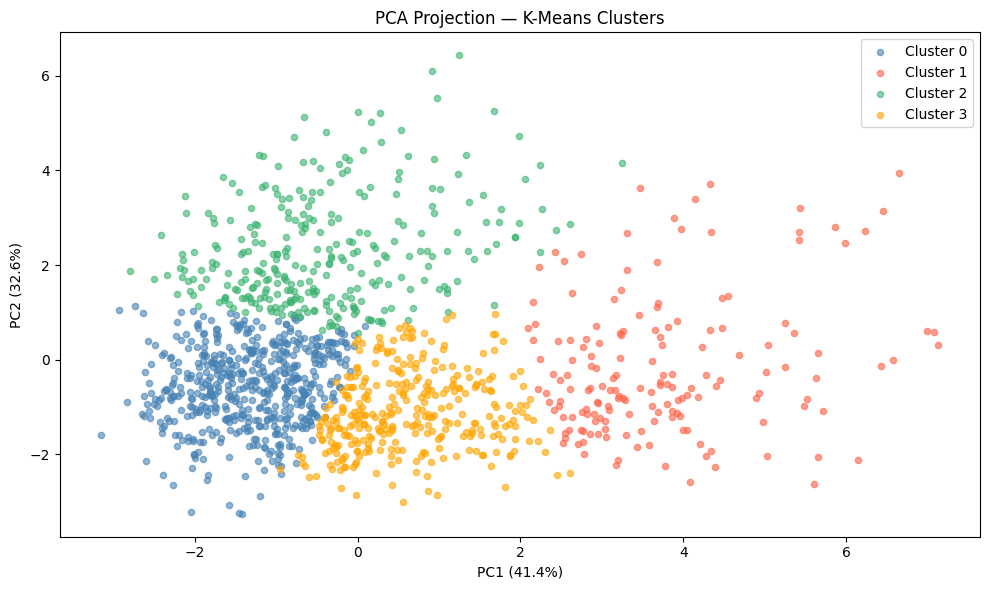

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

variance = pca.explained_variance_ratio_
print(f'PC1 retains: {variance[0]*100:.2f}%')
print(f'PC2 retains: {variance[1]*100:.2f}%')
print(f'Total retained: {sum(variance)*100:.2f}%')

colors = ['steelblue', 'tomato', 'mediumseagreen', 'orange']

plt.figure(figsize=(10, 6))
for i in range(4):
    mask = km_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {i}', alpha=0.6, s=20, color=colors[i])

plt.xlabel(f'PC1 ({variance[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({variance[1]*100:.1f}%)')
plt.title('PCA Projection — K-Means Clusters')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig10_pca_clusters.png', dpi=150)
plt.show()

In [ ]:
df['cluster_label'] = km_labels
cluster_stats = df.groupby('cluster_label')[cluster_cols].mean()
print('Cluster mean statistics:')
print(cluster_stats.round(3).to_string())

Cluster mean statistics:
                  pts    reb    ast  usg_pct  ts_pct  ast_pct  oreb_pct  dreb_pct
cluster_label                                                                    
0               6.125  2.568  1.124    0.151   0.548    0.095     0.034     0.114
1              22.521  6.212  5.959    0.274   0.582    0.274     0.031     0.148
2               8.862  6.054  1.306    0.169   0.611    0.091     0.092     0.199
3              11.653  3.367  3.119    0.200   0.542    0.190     0.023     0.106


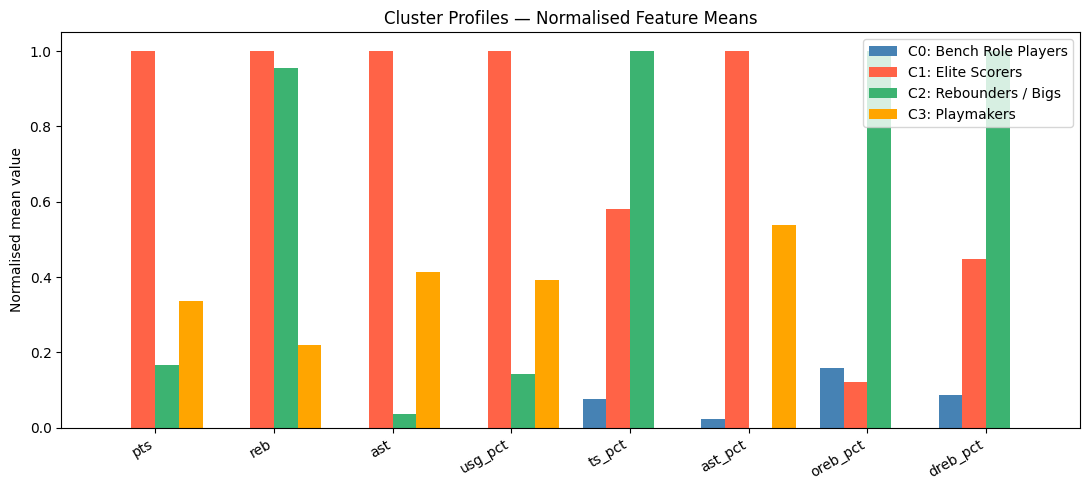

In [ ]:
cluster_stats_norm = (cluster_stats - cluster_stats.min()) / (cluster_stats.max() - cluster_stats.min())

cluster_names = ['Bench Role Players', 'Elite Scorers', 'Rebounders / Bigs', 'Playmakers']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cluster_cols))
width = 0.2

for i in range(4):
    ax.bar(x + i * width, cluster_stats_norm.iloc[i], width=width,
           label=f'C{i}: {cluster_names[i]}', color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cluster_cols, rotation=30, ha='right')
ax.set_ylabel('Normalised mean value')
ax.set_title('Cluster Profiles — Normalised Feature Means')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/fig11_cluster_profiles.png', dpi=150)
plt.show()

In [ ]:
for i in range(4):
    sample = df[df['cluster_label'] == i][['player_name', 'pts', 'reb', 'ast', 'usg_pct']].head(5)
    print(f'\nCluster {i} — {cluster_names[i]}:')
    print(sample.to_string(index=False))


Cluster 0 — Bench Role Players:
    player_name  pts  reb  ast  usg_pct
    Gary Harris  9.9  2.0  2.0    0.164
     Gary Clark  3.1  2.9  0.8    0.097
 Garrett Temple  7.6  2.9  2.2    0.126
   Gabe Vincent  4.8  1.1  1.3    0.184
Frank Ntilikina  2.7  0.9  0.6    0.134

Cluster 1 — Elite Scorers:
          player_name  pts  reb  ast  usg_pct
        Fred VanVleet 19.6  4.2  6.3    0.237
       Gordon Hayward 19.6  5.9  4.1    0.235
Giannis Antetokounmpo 28.1 11.0  5.9    0.320
     Domantas Sabonis 20.3 12.0  6.7    0.239
     Donovan Mitchell 26.4  4.4  5.2    0.327

Cluster 2 — Rebounders / Bigs:
      player_name  pts  reb  ast  usg_pct
Freddie Gillespie  5.6  4.9  0.5    0.120
     Gorgui Dieng  6.8  3.7  1.3    0.169
 Hassan Whiteside  8.1  6.0  0.6    0.227
  Harry Giles III  2.8  3.5  0.8    0.154
   Frank Kaminsky  6.6  4.0  1.7    0.185

Cluster 3 — Playmakers:
    player_name  pts  reb  ast  usg_pct
 Gary Trent Jr. 15.3  2.6  1.4    0.204
    George Hill  8.7  2.0  2.4    

## Cluster Analysis (Task 3.6)

**Cluster 0 — Bench Role Players:** Low points, low usage, average efficiency. These are rotation players who fill defensive or rebounding roles without demanding many possessions.

**Cluster 1 — Elite Scorers:** Highest points per game, highest usage rate, and high true shooting percentage. These are the primary offensive options — star guards and forwards who carry their team's offense.

**Cluster 2 — Rebounders / Bigs:** Elevated offensive and defensive rebound percentages, moderate points, low assist percentage. These are traditional big men whose primary role is interior presence and second-chance opportunities.

**Cluster 3 — Playmakers:** High assist percentage and moderate usage with below-average rebounding. These are point guards and secondary ball-handlers whose role is to create shots for others rather than score themselves.

## Segmentation Interpretation (Task 3.6 — written summary)

The four clusters align well with traditional basketball roles — bench players, scorers, bigs, and playmakers — but emerge purely from statistical patterns rather than positional labels. The separation is reasonably clean in PCA space: Elite Scorers and Rebounders / Bigs occupy distinct regions, while Bench Role Players form the largest and most diffuse cluster, reflecting the diversity within low-usage players. Playmakers and Elite Scorers show some overlap, which makes intuitive sense: high-scoring guards often also create for teammates. The Silhouette Score of ~0.38 confirms moderate but meaningful separation — not perfect, but sufficient to capture genuine structural differences in how players contribute. These clusters can serve as a useful feature in Task 4 to help ensemble models distinguish player roles beyond raw statistics.

In [ ]:
df.to_csv('../data/clustered.csv', index=False)
print('Saved: ../data/clustered.csv')
print('Shape:', df.shape)
print('Cluster distribution:')
print(df['cluster_label'].value_counts().sort_index().to_string())

Saved: ../data/clustered.csv
Shape: (1318, 22)
Cluster distribution:
cluster_label
0    530
1    166
2    298
3    324
